# ResNet-18 Fine-tuning on RAF-DB
### Sentiment Analysis
>

## 1 — Setup

In [1]:
!pip uninstall -q -y onnxruntime
!pip install -q onnxruntime-gpu
!pip install -q kagglehub Pillow numpy matplotlib tqdm
print("✅ Done.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 252.8/252.8 MB 5.3 MB/s eta 0:00:00
✅ Done.


In [2]:
import os, numpy as np, torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
import matplotlib.pyplot as plt
from tqdm import tqdm
import warnings
warnings.filterwarnings("ignore")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

BASE_DIR       = "/content/echovision_training"
WEIGHTS_DIR    = os.path.join(BASE_DIR, "weights")
os.makedirs(WEIGHTS_DIR, exist_ok=True)
RESNET_WEIGHTS = os.path.join(WEIGHTS_DIR, "resnet18_rafdb.pth")
EMOTION_LABELS = ["surprise", "fear", "disgust", "happy", "sad", "angry", "neutral"]
print(f"Weights path: {RESNET_WEIGHTS}")

Device: cuda
Weights path: /content/echovision_training/weights/resnet18_rafdb.pth


## 2 — Download RAF-DB

In [3]:
import kagglehub
path = kagglehub.dataset_download("shuvoalok/raf-db-dataset")
RAFDB_DIR = os.path.join(path, "DATASET")
print(f"✅ RAF-DB ready at: {RAFDB_DIR}")

Using Colab cache for faster access to the 'raf-db-dataset' dataset.
✅ RAF-DB ready at: /kaggle/input/raf-db-dataset/DATASET


## 3 — Dataset & Transforms

In [4]:
class RAFDBDataset(Dataset):
    def __init__(self, root, split="train", transform=None):
        self.transform = transform
        self.samples   = []
        split_dir = os.path.join(root, split)
        for cls in sorted(os.listdir(split_dir)):
            cls_path = os.path.join(split_dir, cls)
            if not os.path.isdir(cls_path):
                continue
            label = int(cls) - 1
            for fname in os.listdir(cls_path):
                if fname.lower().endswith((".jpg", ".jpeg", ".png")):
                    self.samples.append((os.path.join(cls_path, fname), label))
        print(f"[{split}] {len(self.samples)} images")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, label

print("✅ RAFDBDataset defined.")

✅ RAFDBDataset defined.


In [5]:
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.3, contrast=0.3),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])
print("✅ Transforms defined.")

✅ Transforms defined.


## 4 — Model

In [6]:
def build_sentiment_model(num_classes=7, pretrained=True):
    model = models.resnet18(pretrained=pretrained)
    model.fc = nn.Sequential(
        nn.Dropout(0.4),
        nn.Linear(model.fc.in_features, num_classes)
    )
    return model.to(DEVICE)

print("✅ build_sentiment_model() defined.")

✅ build_sentiment_model() defined.


## 5 — Training

In [7]:
def train_sentiment_model(rafdb_root, epochs=30, batch_size=64, lr=1e-4, patience=7):
    train_ds     = RAFDBDataset(rafdb_root, "train", train_transforms)
    val_ds       = RAFDBDataset(rafdb_root, "test",  val_transforms)
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,  num_workers=2, pin_memory=True)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

    model     = build_sentiment_model(pretrained=True)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam([
        {"params": list(model.parameters())[:-2], "lr": lr * 0.1},
        {"params": list(model.parameters())[-2:], "lr": lr},
    ])
    scheduler       = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    best_val_acc    = 0.0
    epochs_no_improve = 0
    history         = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

    for epoch in range(1, epochs + 1):
        # Train
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        for imgs, labels in tqdm(train_loader, desc=f"Epoch {epoch:02d}/{epochs} [train]"):
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss    = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * imgs.size(0)
            correct      += (outputs.argmax(1) == labels).sum().item()
            total        += imgs.size(0)
        train_loss = running_loss / total
        train_acc  = correct / total

        # Validate
        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for imgs, labels in tqdm(val_loader, desc=f"Epoch {epoch:02d}/{epochs} [val]  "):
                imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
                outputs      = model(imgs)
                loss         = criterion(outputs, labels)
                val_loss    += loss.item() * imgs.size(0)
                val_correct += (outputs.argmax(1) == labels).sum().item()
                val_total   += imgs.size(0)
        val_loss /= val_total
        val_acc   = val_correct / val_total
        scheduler.step()

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(f"Epoch {epoch:02d} | Train Loss: {train_loss:.4f}  Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f}  Acc: {val_acc:.4f}")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            epochs_no_improve = 0
            torch.save(model.state_dict(), RESNET_WEIGHTS)
            print(f"  ✅ Best model saved (val_acc={best_val_acc:.4f})")
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"  ⏹ Early stopping at epoch {epoch} (no improvement for {patience} epochs)")
                break

    print(f"\nTraining complete. Best Val Accuracy: {best_val_acc:.4f}")

    # Plot
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(history["train_loss"], label="Train"); ax1.plot(history["val_loss"], label="Val")
    ax1.set_title("Loss"); ax1.legend(); ax1.grid(True, alpha=0.3)
    ax2.plot(history["train_acc"], label="Train"); ax2.plot(history["val_acc"], label="Val")
    ax2.set_title("Accuracy"); ax2.legend(); ax2.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()

    return model

print("✅ train_sentiment_model() defined.")

✅ train_sentiment_model() defined.


### Run Training
>

[train] 12271 images
[test] 3068 images
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 78.1MB/s]
Epoch 01/30 [val]  : 100%|██████████| 48/48 [00:16<00:00,  2.85it/s]


Epoch 01 | Train Loss: 1.6142  Acc: 0.3933 | Val Loss: 1.3149  Acc: 0.5372
  ✅ Best model saved (val_acc=0.5372)


Epoch 02/30 [val]  : 100%|██████████| 48/48 [00:07<00:00,  6.34it/s]


Epoch 02 | Train Loss: 1.2347  Acc: 0.5555 | Val Loss: 1.0881  Acc: 0.6219
  ✅ Best model saved (val_acc=0.6219)


...

Epoch 28 | Train Loss: 0.3968  Acc: 0.8599 | Val Loss: 0.5340  Acc: 0.8123
  ✅ Best model saved (val_acc=0.8123)


Epoch 29/30 [val]  : 100%|██████████| 48/48 [00:08<00:00,  5.99it/s]


Epoch 29 | Train Loss: 0.3903  Acc: 0.8621 | Val Loss: 0.5346  Acc: 0.8103


Epoch 30/30 [val]  : 100%|██████████| 48/48 [00:08<00:00,  5.97it/s]


Epoch 30 | Train Loss: 0.3911  Acc: 0.8642 | Val Loss: 0.5335  Acc: 0.8087

Training complete. Best Val Accuracy: 0.8123


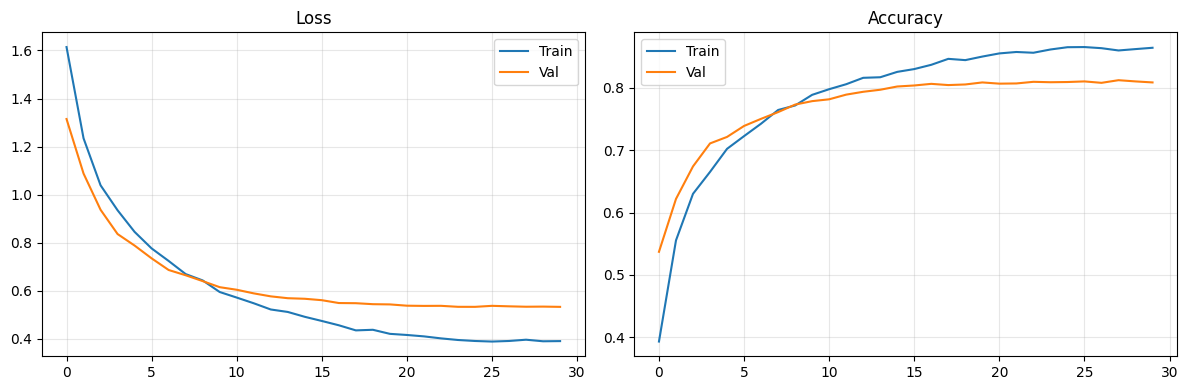

In [8]:
sentiment_model = train_sentiment_model(
    rafdb_root = RAFDB_DIR,
    epochs     = 30,
    batch_size = 64,
    lr         = 1e-4,
    patience   = 7
)

In [12]:
import os
for root, dirs, files in os.walk('/content'):
    for file in files:
        if file.endswith('.pth'):
            print(os.path.join(root, file))

/content/echovision_training/weights/resnet18_rafdb.pth


In [13]:
import shutil, os
from google.colab import drive
drive.mount('/content/drive')
os.makedirs("/content/drive/MyDrive/EchoVision", exist_ok=True)
shutil.copy(
    "/content/echovision_training/weights/resnet18_rafdb.pth",
    "/content/drive/MyDrive/EchoVision/resnet18_rafdb.pth"
)
print("ResNet-18 weights saved to Drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
ResNet-18 weights saved to Drive


## 6 — Save Weights

In [ ]:
# Save to Google Drive
from google.colab import drive
import shutil

drive.mount('/content/drive')
os.makedirs("/content/drive/MyDrive/EchoVision/weights", exist_ok=True)
shutil.copy(RESNET_WEIGHTS, "/content/drive/MyDrive/EchoVision/weights/resnet18_rafdb.pth")
print("✅ Saved to Google Drive → EchoVision/weights/resnet18_rafdb.pth")

Mounted at /content/drive
✅ Saved to Google Drive → EchoVision/weights/resnet18_rafdb.pth


In [ ]:
# Download to your computer
from google.colab import files
files.download(RESNET_WEIGHTS)
print("✅ Download started.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Download started.


## 7 — Verify Saved Model

In [ ]:
def load_sentiment_model(weights_path):
    model = build_sentiment_model(pretrained=False)
    model.load_state_dict(torch.load(weights_path, map_location=DEVICE))
    model.eval()
    return model

# Load and test
loaded_model = load_sentiment_model(RESNET_WEIGHTS)
dummy = torch.randn(1, 3, 224, 224).to(DEVICE)
with torch.no_grad():
    out = loaded_model(dummy)
print(f"✅ Model loaded and verified. Output shape: {out.shape}")
print(f"   Emotion classes: {EMOTION_LABELS}")

✅ Model loaded and verified. Output shape: torch.Size([1, 7])
   Emotion classes: ['surprise', 'fear', 'disgust', 'happy', 'sad', 'angry', 'neutral']
